# Backpropagation in Multilayer Neural Networks

While we will primarily be working with high-level, abstract toolkits like Keras in this course, understanding how backpropagation works is absolutely essential to using neural networks. 

In this exercise, we will build our own backpropagation algorithm - working through each step, to ensure that we can follow it.

Just like in Lab 1, we'll be working with the MNIST dataset. We will load it and plot an example:

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

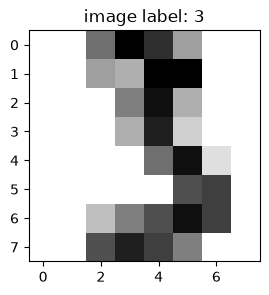

In [2]:
sample_index = 45
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[sample_index], cmap=plt.cm.gray_r,
           interpolation='nearest')
plt.title("image label: %d" % digits.target[sample_index]);

### Preprocessing

Of course, we need to split our data into training and testing sets before we use it, just the same as in Lab 1:

In [3]:
from sklearn.model_selection import train_test_split

data = np.asarray(digits.data, dtype='float32')
target = np.asarray(digits.target, dtype='int32')

X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.15, random_state=37)

# Numpy Implementation

## a) Logistic Regression

In this section we will implement a logistic regression model trainable with SGD using numpy. Here are the objectives:

- Implement the softmax function $\sigma(\mathbf{x})_i = \frac{e^{x_i}}{\sum_{j=1}^n e^{x_j}}$;
- Implement the negative log likelihood function $NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}$;
- Train a logistic regression model on the MNIST dataset;
- Evaluate the model on the training and testing sets.

Before we get there, let's write a function that one-hot encodes the class labels:

In [4]:
def one_hot(n_classes, y):
    return np.eye(n_classes)[y]

In [5]:
one_hot(n_classes=10, y=3)

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [6]:
one_hot(n_classes=10, y=[0, 4, 9, 1])

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

### The softmax function

Now we will implement the softmax function. Recall that the softmax function is defined as follows:

$$
softmax(\mathbf{x}) = \frac{1}{\sum_{i=1}^{n}{e^{x_i}}}
\cdot
\begin{bmatrix}
  e^{x_1}\\\\
  e^{x_2}\\\\
  \vdots\\\\
  e^{x_n}
\end{bmatrix}
$$

This is implemented for you using numpy - we want to be able to apply the softmax function to a batch of samples at once, so we will use numpy's vectorized operations to do so.

Our method also handles _stability issues_ that can occur when the values in `X` are very large. We will subtract the maximum value from each row of `X` to avoid overflow in the exponentiation. This isn't part of the softmax function itself, but it's a useful trick to know about.

In [7]:
def softmax(X):
    X_max = np.max(X, axis=-1, keepdims=True)
    exp = np.exp(X - X_max) # Subtract the max to avoid overflow in the exponentiation
    return exp / np.sum(exp, axis=-1, keepdims=True)


Let's make sure that this works one vector at a time (and check that the components sum to one):

In [8]:
print(softmax([10, 2, -3]))

[9.99662391e-01 3.35349373e-04 2.25956630e-06]


When we are using our model to make predictions, we will want to be able to make predictions for multiple samples at once.
Let's make sure that our implementation of softmax works for a batch of samples:

In [9]:
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


Probabilities should sum to 1:

In [10]:
print(np.sum(softmax([10, 2, -3])))

1.0


In [11]:
print("softmax of 2 vectors:")
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

softmax of 2 vectors:
[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


The sum of probabilities for each input vector of logits should some to 1:

In [12]:
print(np.sum(softmax(X), axis=1))

[1. 1.]


Now we will implement a function that, given the true one-hot encoded class `Y_true` and some predicted probabilities `Y_pred`, returns the negative log likelihood.

Recall that the negative log likelihood is defined as follows:

$$
NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}
$$

For example, if we have $y_{true} = [1, 0, 0]$ and $y_{pred} = [0.99, 0.01, 0]$, then the negative log likelihood is $- \log(0.99) \approx 0.01$.

In [13]:
def nll(Y_true, Y_pred):
    Y_true = np.asarray(Y_true)
    Y_pred = np.asarray(Y_pred)

    # Ensure Y_pred doesn't have zero probabilities to avoid log(0)
    Y_pred = np.clip(Y_pred, 1e-15, 1 - 1e-15)

    # Calculate negative log likelihood
    loss = -np.sum(Y_true * np.log(Y_pred))
    return loss

# Make sure that it works for a simple sample at a time
print(nll([1, 0, 0], [.99, 0.01, 0]))

0.01005033585350145


We should see a very high value for this negative log likelihood, since the model is very confident that the third class is the correct one, but the true class is the first one:

In [14]:
print(nll([1, 0, 0], [0.01, 0.01, .98]))

4.605170185988091


Make sure that your implementation can compute the average negative log likelihood of a group of predictions: `Y_pred` and `Y_true` can therefore be past as 2D arrays:

In [15]:
# Check that the average NLL of the following 3 almost perfect
# predictions is close to 0
Y_true = np.array([[0, 1, 0],
                   [1, 0, 0],
                   [0, 0, 1]])

Y_pred = np.array([[0,   1,    0],
                   [.99, 0.01, 0],
                   [0,   0,    1]])

print(nll(Y_true, Y_pred))

0.010050335853503449


Now that we have our softmax and negative log likelihood functions, we can implement a logistic regression model. 
In this section, we have built the model for you, but you will need to complete a few key parts.

**YOUR TURN:**

1. Implement the `forward` method of the `LogisticRegression` class. This method should take in a batch of samples `X` and return the predicted probabilities for each class. You should use the softmax function that we implemented earlier.
2. Implement the `loss` method of the `LogisticRegression` class. This method take in the samples `X` and the true values `y` and return the average negative log likelihood of the predictions.

In [16]:
class LogisticRegression:

    def __init__(self, input_size, output_size):
        # Initialize the weights and biases with random numbers
        self.W = np.random.uniform(size=(input_size, output_size),
                                   high=0.1, low=-0.1)
        self.b = np.random.uniform(size=output_size,
                                   high=0.1, low=-0.1)
        
        # Store the input size and output size
        self.output_size = output_size
        self.input_size = input_size
        
    def forward(self, X):
        # Compute the linear combination of the input and weights
        #Z = None
        #return None
        # Compute the linear combination
        Z = np.dot(X, self.W) + self.b

       # Apply softmax to obtain class probabilities
        return softmax(Z)
    
    def predict(self, X):
        # Return the most probable class for each sample in X
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)
            
    def loss(self, X, y):
        # Compute the negative log likelihood over the data provided
        y_onehot = one_hot(self.output_size, y.astype(int))
       
        # Get predicted probabilities
        y_pred = self.forward(X)
        # Prevent log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

        # Compute average negative log-likelihood
        loss = -np.mean(np.sum(y_onehot * np.log(y_pred), axis=1))

        return loss

    def grad_loss(self, X, y_true, y_pred):
        # Compute the gradient of the loss with respect to W and b for a single sample (X, y_true)
        # y_pred is the output of the forward pass
    
        # Gradient with respect to weights
        grad_W = np.dot(X.T, (y_pred - y_true))
    
        # Gradient with respect to biases
        grad_b = np.sum(y_pred - y_true, axis=0)
    
        return grad_W, grad_b
    
# Raise an exception if you try to run this cell without having implemented the LogisticRegression class
model = LogisticRegression(input_size=64, output_size=10)
try:
    assert(model.forward(np.zeros((1, 64))).shape == (1, 10))
    assert(model.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the LogisticRegression class.")

In [17]:
# Build a model and test its forward inference
n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))
lr = LogisticRegression(n_features, n_classes)

We can evaluate the model on an example, visualizing the prediction probabilities:

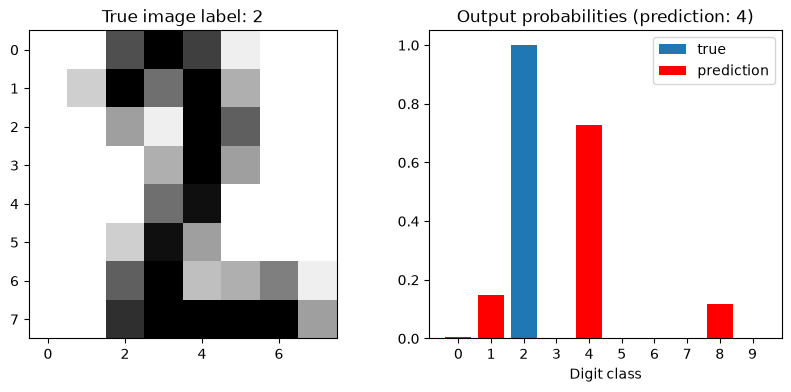

In [18]:
def plot_prediction(model, sample_idx=0, classes=range(10)):
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

    ax0.imshow(X_test[sample_idx:sample_idx+1].reshape(8, 8),
               cmap=plt.cm.gray_r, interpolation='nearest')
    ax0.set_title("True image label: %d" % y_test[sample_idx]);


    ax1.bar(classes, one_hot(len(classes), y_test[sample_idx]), label='true')
    ax1.bar(classes, model.forward(X_test[sample_idx]), label='prediction', color="red")
    ax1.set_xticks(classes)
    prediction = model.predict(X_test[sample_idx])
    ax1.set_title('Output probabilities (prediction: %d)'
                  % prediction)
    ax1.set_xlabel('Digit class')
    ax1.legend()

plot_prediction(lr, sample_idx=0)
    

Now it's time to start training! We will train for a single epoch, and then evaluate the model on the training and testing sets. Read through the following and make sure that you understand what we are doing here.

In [19]:
lr = LogisticRegression(input_size=X_train.shape[1], output_size=10)

learning_rate = 0.01

for i in range(len(X_train)):
    # Get the current sample and corresponding label
    x = X_train[i:i+1]  # Reshape to keep the batch dimension
    y = y_train[i:i+1]  # Reshape to keep the batch dimension

    # Compute the forward pass and the gradient of the loss with respect to W and b
    y_pred = lr.forward(x)
    grad_W, grad_b = lr.grad_loss(x, one_hot(lr.output_size, y), y_pred)

    # Update the weights and biases
    lr.W -= learning_rate * grad_W
    lr.b -= learning_rate * grad_b

    # Print the average negative log likelihood every 100 steps (avoid empty slice at i==0)
    if i > 0 and i % 100 == 0:
        avg_nll = lr.loss(X_train[max(0, i-100):i], y_train[max(0, i-100):i])
        print("Average NLL over the last 100 samples at step %d: %0.f" % (i, avg_nll))


Average NLL over the last 100 samples at step 100: 5
Average NLL over the last 100 samples at step 200: 3
Average NLL over the last 100 samples at step 300: 1
Average NLL over the last 100 samples at step 400: 1
Average NLL over the last 100 samples at step 500: 2
Average NLL over the last 100 samples at step 600: 1
Average NLL over the last 100 samples at step 700: 1
Average NLL over the last 100 samples at step 800: 1
Average NLL over the last 100 samples at step 900: 1
Average NLL over the last 100 samples at step 1000: 2
Average NLL over the last 100 samples at step 1100: 1
Average NLL over the last 100 samples at step 1200: 2
Average NLL over the last 100 samples at step 1300: 1
Average NLL over the last 100 samples at step 1400: 1
Average NLL over the last 100 samples at step 1500: 0


Evaluate the trained model on the first example:

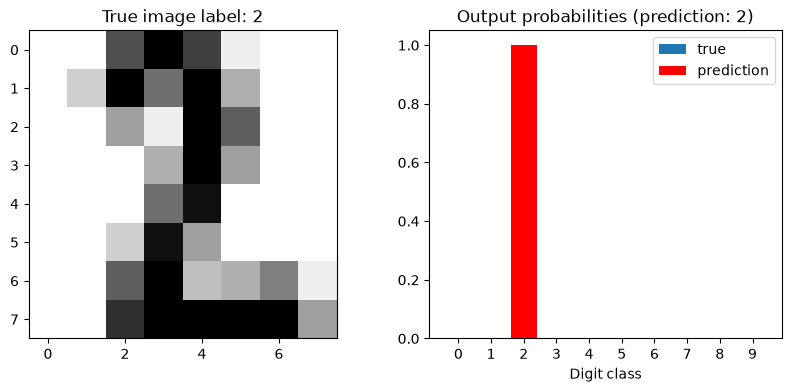

In [20]:
plot_prediction(lr, sample_idx=0)

## b) Feedforward Multilayer

The objective of this section is to implement the backpropagation algorithm (SGD with the chain rule) on a single layer neural network using the sigmoid activation function.

Now it's your turn to

- Implement the `sigmoid` and its element-wise derivative `dsigmoid` functions:

$$
sigmoid(x) = \frac{1}{1 + e^{-x}}
$$

$$
dsigmoid(x) = sigmoid(x) \cdot (1 - sigmoid(x))
$$

Remember that you can use your `sigmoid` function inside your `dsigmoid` function.

Just like with our softmax function, we also want to make sure that we don't run into stability issues with our sigmoid function. We will use `np.clip` to ensure that the input to the sigmoid function is not too large or too small.

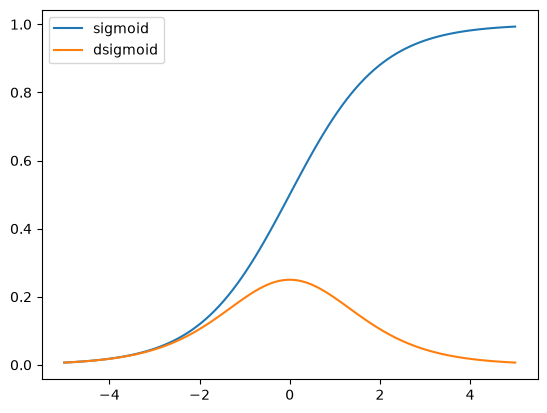

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(X):
    # Clip X to prevent overflow or underflow
    X = np.clip(X, -500, 500) # This ensures that np.exp(X) doesn't overflow
    # Compute sigmoid
    return 1 / (1 + np.exp(-X))
  

def dsigmoid(X):
     s = sigmoid(X)
     return s * (1 - s)


x = np.linspace(-5, 5, 100)
plt.plot(x, sigmoid(x), label='sigmoid')
plt.plot(x, dsigmoid(x), label='dsigmoid')
plt.legend(loc='best');

Now it's your turn to complete the neural network code, so that we can train it on the MNIST dataset.

Some parts have been completed for you already. Often, you'll be able to refer back to the code from the previous section to help you complete the code in this section.

In [22]:
class NeuralNet():
    """MLP with 1 hidden layer with a sigmoid activation"""

    def __init__(self, input_size, hidden_size, output_size):
        # Initializes the weights with random numbers
        self.W_h = np.random.uniform(size=(input_size, hidden_size),
                                     high=0.1, low=-0.1)
        self.b_h = np.random.uniform(size=hidden_size,
                                     high=0.1, low=-0.1)
        self.W_o = np.random.uniform(size=(hidden_size, output_size),
                                     high=0.1, low=-0.1)
        self.b_o = np.random.uniform(size=output_size,
                                     high=0.1, low=-0.1)

        # Store the input size, hidden size and output size
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

    def forward_hidden(self, X):
        # Compute the linear combination of the input and weights
        self.Z_h = np.dot(X, self.W_h) + self.b_h
        # Hidden-layer activation
        self.H = sigmoid(self.Z_h)

        # Apply the sigmoid activation function
        return self.H

    def forward_output(self, H):
        # Compute the linear combination of the hidden layer activation and weights
        self.Z_o = np.dot(H, self.W_o) + self.b_o
        # Output-layer activation
        self.Y = sigmoid(self.Z_o)

        # Apply the sigmoid activation function
        return self.Y


    def forward(self, X):
        # Ensure the input is a NumPy array
        X = np.asarray(X)
        
        # Compute the forward activations of the hidden and output layers
        H = self.forward_hidden(X)
        Y = self.forward_output(H)

        return Y

    def loss(self, X, y):
        y = y.astype(int)
        
        # Convert class labels to one-hot vectors
        y_true = one_hot(self.output_size, y)

        # Compute predicted probabilities
        y_pred = self.forward(X)

        # Prevent log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)

        # Binary cross-entropy across output neurons
        sample_losses = -np.sum(
            y_true * np.log(y_pred)
            + (1.0 - y_true) * np.log(1.0 - y_pred),
            axis=1
        )

        # Return average loss
        return np.mean(sample_losses)
        
    def grad_loss(self, X, y_true):
        y_true = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)

        # Compute the error at the output layer
        error_o = y_pred - y_true

        # Compute the gradient of the loss with respect to W_o and b_o
        grad_W_o = np.dot(self.Z_h.T, error_o)
        grad_b_o = np.sum(error_o, axis=0)

        # Compute the error at the hidden layer
        error_h = np.dot(error_o, self.W_o.T) * dsigmoid(self.Z_h)

        # Compute the gradient of the loss with respect to W_h and b_h
        grad_W_h = np.dot(X.T, error_h)
        grad_b_h = np.sum(error_h, axis=0)

        return {"W_h": grad_W_h, "b_h": grad_b_h, "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, x, y, learning_rate):
        # Ensure x is 2D
        x = x[np.newaxis, :]
        # Compute the gradient for the sample and update the weights
        grads = self.grad_loss(x, y)
    
        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]
        
    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        y_preds = np.argmax(self.forward(X), axis=1)
        return np.mean(y_preds == y)
    
# Raise an exception if you try to run this cell without having implemented the NeuralNet class
nn = NeuralNet(input_size=64, hidden_size=32, output_size=10)
try:
    assert(nn.forward(np.zeros((1, 64))).shape == (1, 10))
    assert(nn.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the NeuralNet class.")

Once the code is written, we can test our model on a single sample:

In [23]:
n_hidden = 10
model = NeuralNet(n_features, n_hidden, n_classes)

In [24]:
model.loss(X_train, y_train)

np.float64(6.91559672062629)

In [25]:
model.accuracy(X_train, y_train)

np.float64(0.13228552717747216)

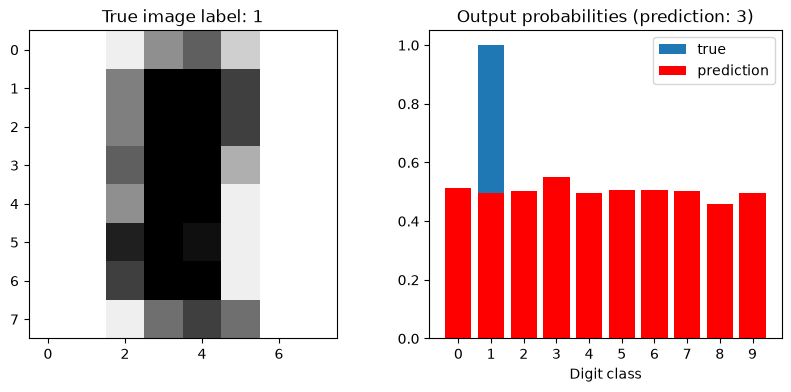

In [26]:
plot_prediction(model, sample_idx=5)

And now it's time to train!

In [27]:
losses, accuracies, accuracies_test = [], [], []
losses.append(model.loss(X_train, y_train))
accuracies.append(model.accuracy(X_train, y_train))
accuracies_test.append(model.accuracy(X_test, y_test))

print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
      % (losses[-1], accuracies[-1], accuracies_test[-1]))

for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.001)

    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))

Random init: train loss: 6.91560, train acc: 0.132, test acc: 0.089
Epoch #1, train loss: 3.11517, train acc: 0.265, test acc: 0.219
Epoch #2, train loss: 2.70009, train acc: 0.538, test acc: 0.474
Epoch #3, train loss: 2.29257, train acc: 0.712, test acc: 0.619
Epoch #4, train loss: 1.91473, train acc: 0.773, test acc: 0.693
Epoch #5, train loss: 1.59685, train acc: 0.850, test acc: 0.781
Epoch #6, train loss: 1.35839, train acc: 0.893, test acc: 0.856
Epoch #7, train loss: 1.18378, train acc: 0.915, test acc: 0.896
Epoch #8, train loss: 1.05855, train acc: 0.927, test acc: 0.904
Epoch #9, train loss: 0.96776, train acc: 0.927, test acc: 0.907
Epoch #10, train loss: 0.89000, train acc: 0.935, test acc: 0.919
Epoch #11, train loss: 0.82458, train acc: 0.939, test acc: 0.915
Epoch #12, train loss: 0.77909, train acc: 0.942, test acc: 0.922
Epoch #13, train loss: 0.72612, train acc: 0.942, test acc: 0.930
Epoch #14, train loss: 0.69023, train acc: 0.944, test acc: 0.922
Epoch #15, train 

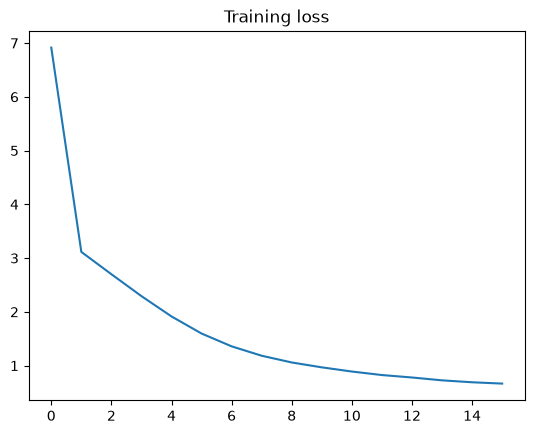

In [28]:
plt.plot(losses)
plt.title("Training loss");

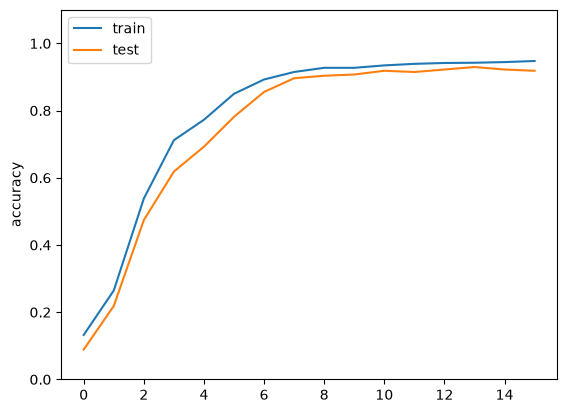

In [29]:
plt.plot(accuracies, label='train')
plt.plot(accuracies_test, label='test')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.legend(loc='best');

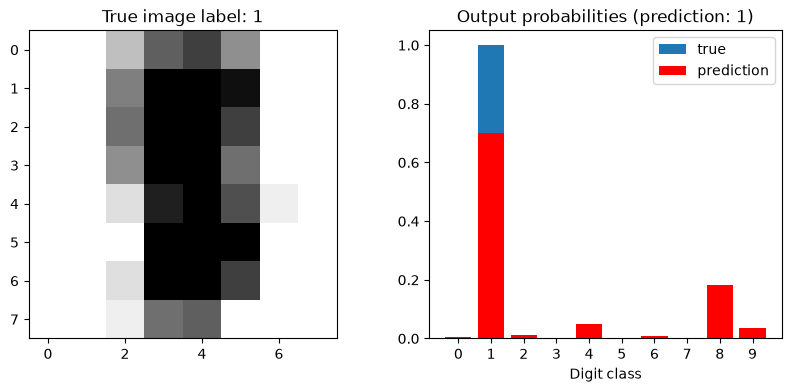

In [30]:
plot_prediction(model, sample_idx=4)

## c) Exercises

### Look at worst prediction errors

- Use numpy to find test samples for which the model made the worst predictions,
- Use the `plot_prediction` to look at the model predictions on those,
- Would you have done any better?

In [31]:
#Use numpy to find test samples for which the model made the worst predictions,
import numpy as np

# Get predicted probabilities on the test set
y_pred = nn.forward(X_test)

# Probability assigned to the true class
true_class_probs = y_pred[np.arange(len(y_test)), y_test]

# Predicted labels
predictions = np.argmax(y_pred, axis=1)

# Find incorrectly classified samples
incorrect = predictions != y_test

# Select only the incorrect predictions
incorrect_indices = np.where(incorrect)[0]

# Their probabilities for the true class
incorrect_probs = true_class_probs[incorrect]

# Sort from worst (lowest probability assigned to the true class)
worst_order = np.argsort(incorrect_probs)

# Top 10 worst predictions
worst_indices = incorrect_indices[worst_order[:10]]

print("Worst prediction indices:")
print(worst_indices)

print("\nTrue labels:")
print(y_test[worst_indices])

print("\nPredicted labels:")
print(predictions[worst_indices])

print("\nProbability assigned to the true class:")
print(true_class_probs[worst_indices])

Worst prediction indices:
[ 29  98  73  95 214 124 192 162 229 196]

True labels:
[7 7 7 7 7 7 7 7 1 7]

Predicted labels:
[9 9 4 9 2 4 4 4 4 8]

Probability assigned to the true class:
[0.38553898 0.39115674 0.39128397 0.39303344 0.40286749 0.41713186
 0.41880162 0.42584881 0.4277508  0.43143189]


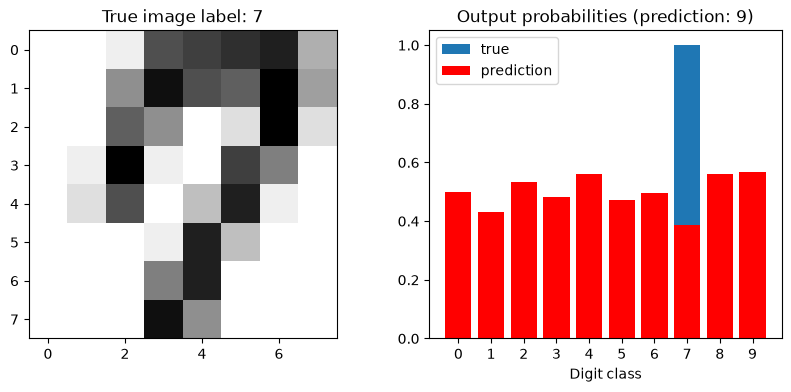

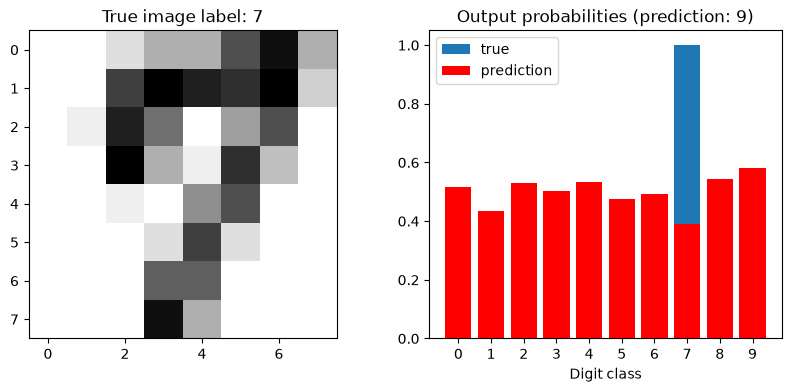

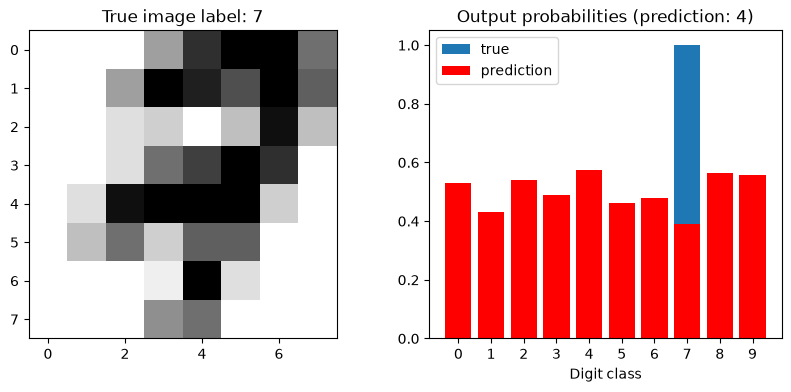

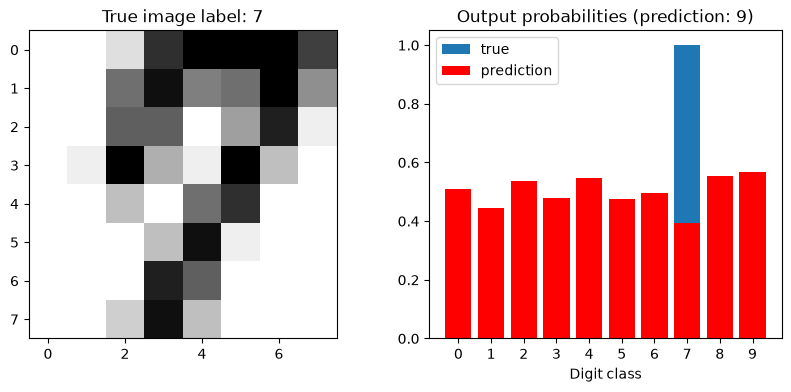

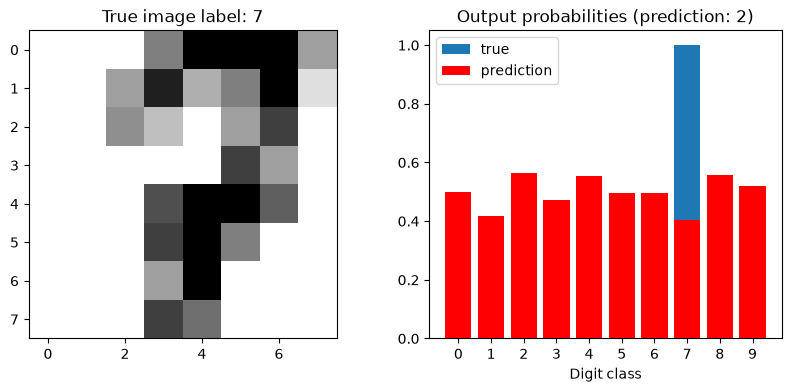

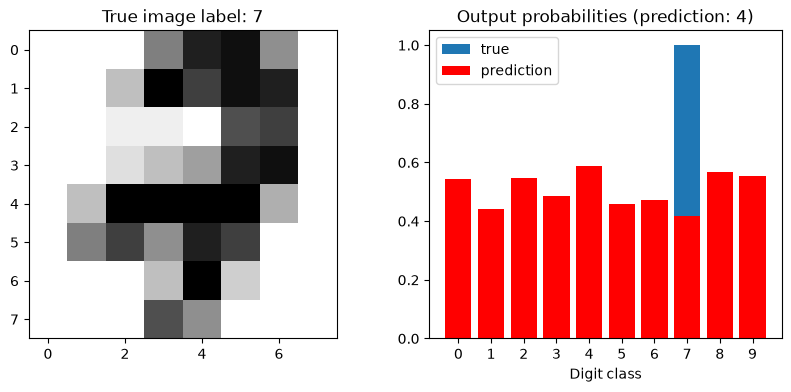

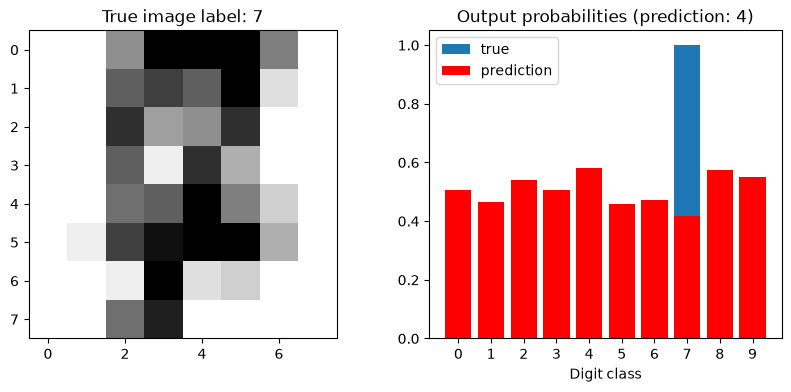

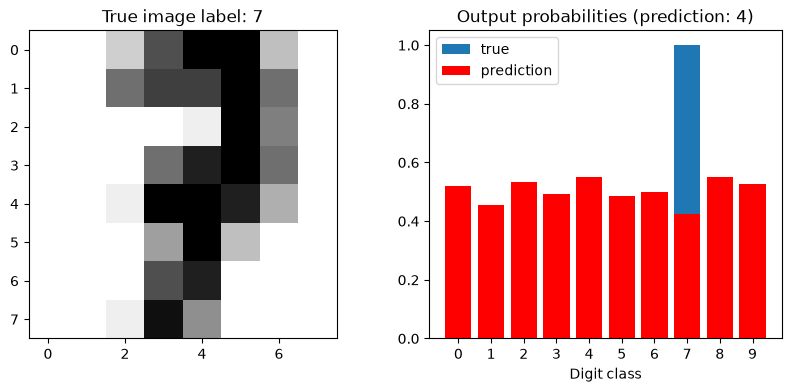

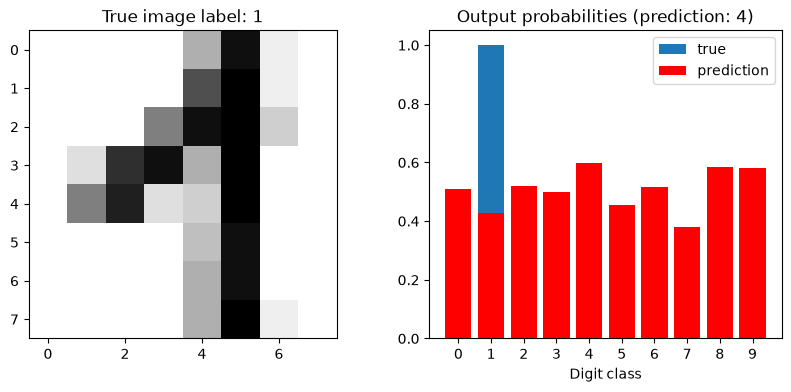

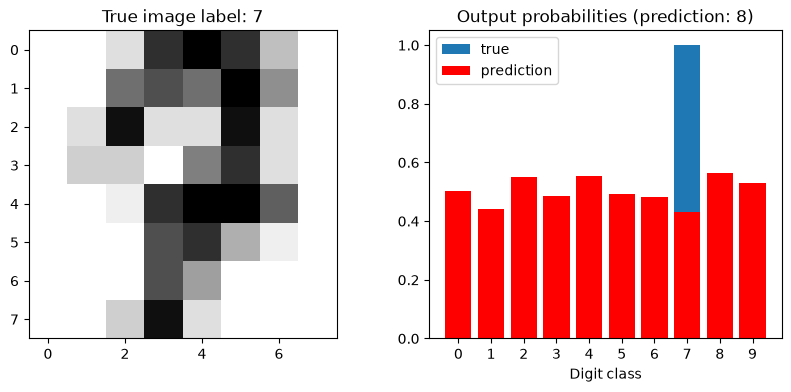

In [32]:
#Use the plot_prediction to look at the model predictions on those,
# Display the 10 worst predictions

for idx in worst_indices[:10]:
    plot_prediction(nn, sample_idx=idx)

#What would I have done better?
In some cases, I may have classified the images better than the model because a human can use the overall shape of the digit and interpret unusual handwriting more flexibly. However, some of the worst samples are very ambiguous and could easily be mistaken for another digit, even by a person. For example, a poorly written 3 may resemble a 5, or a 4 may resemble a 9. Therefore, I would probably perform better on some samples, but not necessarily on all of them. The model’s mistakes are understandable because it has only one hidden layer and learns from pixel patterns rather than understanding the digit in the same way a human does.


### Hyper parameters settings

- Experiment with different hyperparameters:
  - learning rate,
  - size of hidden layer,
  - implement the support for a second hidden layer.
  - What is the best test accuracy you can get?

In [33]:
## Different Learning Rates
import numpy as np
import matplotlib.pyplot as plt

# Learning rates to test
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]

# Number of passes through the training data
epochs = 20

results = {}

for learning_rate in learning_rates:
    # Use the same seed so each model starts with the same weights
    np.random.seed(42)

    model = LogisticRegression(
        input_size=X_train.shape[1],
        output_size=10
    )

    epoch_losses = []
    epoch_train_accuracies = []
    epoch_test_accuracies = []

    for epoch in range(epochs):
        # Shuffle the training data at the beginning of each epoch
        indices = np.random.permutation(len(X_train))

        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]

        # Train one sample at a time
        for i in range(len(X_train_shuffled)):
            x = X_train_shuffled[i:i + 1]
            y = y_train_shuffled[i:i + 1]

            # Forward pass
            y_pred = model.forward(x)

            # Convert the true label to one-hot format
            y_true = one_hot(model.output_size, y.astype(int))

            # Calculate gradients
            grad_W, grad_b = model.grad_loss(
                x,
                y_true,
                y_pred
            )

            # Update weights and biases
            model.W -= learning_rate * grad_W
            model.b -= learning_rate * grad_b

        # Calculate loss after the epoch
        train_loss = model.loss(X_train, y_train)

        # Calculate predictions
        train_predictions = model.predict(X_train)
        test_predictions = model.predict(X_test)

        # Calculate accuracies
        train_accuracy = np.mean(
            train_predictions == y_train
        )

        test_accuracy = np.mean(
            test_predictions == y_test
        )

        epoch_losses.append(train_loss)
        epoch_train_accuracies.append(train_accuracy)
        epoch_test_accuracies.append(test_accuracy)

        print(
            f"Learning rate: {learning_rate:<7} | "
            f"Epoch: {epoch + 1:>2}/{epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Train accuracy: {train_accuracy:.4f} | "
            f"Test accuracy: {test_accuracy:.4f}"
        )

    # Store results for this learning rate
    results[learning_rate] = {
        "model": model,
        "loss": epoch_losses,
        "train_accuracy": epoch_train_accuracies,
        "test_accuracy": epoch_test_accuracies
    }

    print("-" * 90)

Learning rate: 0.0001  | Epoch:  1/20 | Loss: 0.6150 | Train accuracy: 0.8330 | Test accuracy: 0.8148
Learning rate: 0.0001  | Epoch:  2/20 | Loss: 0.3637 | Train accuracy: 0.9116 | Test accuracy: 0.9074
Learning rate: 0.0001  | Epoch:  3/20 | Loss: 0.2776 | Train accuracy: 0.9325 | Test accuracy: 0.9296
Learning rate: 0.0001  | Epoch:  4/20 | Loss: 0.2295 | Train accuracy: 0.9489 | Test accuracy: 0.9444
Learning rate: 0.0001  | Epoch:  5/20 | Loss: 0.2015 | Train accuracy: 0.9515 | Test accuracy: 0.9444
Learning rate: 0.0001  | Epoch:  6/20 | Loss: 0.1805 | Train accuracy: 0.9581 | Test accuracy: 0.9556
Learning rate: 0.0001  | Epoch:  7/20 | Loss: 0.1657 | Train accuracy: 0.9627 | Test accuracy: 0.9556
Learning rate: 0.0001  | Epoch:  8/20 | Loss: 0.1546 | Train accuracy: 0.9659 | Test accuracy: 0.9593
Learning rate: 0.0001  | Epoch:  9/20 | Loss: 0.1484 | Train accuracy: 0.9712 | Test accuracy: 0.9593
Learning rate: 0.0001  | Epoch: 10/20 | Loss: 0.1406 | Train accuracy: 0.9712 | Te

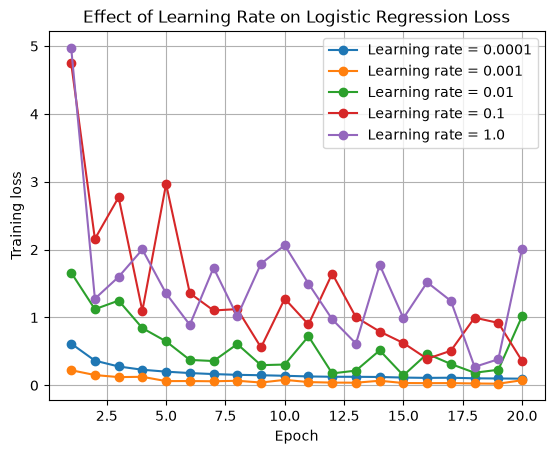

In [34]:
#Plot training loss
# plt.figure(figsize=(10, 6))

for learning_rate in learning_rates:
    plt.plot(
        range(1, epochs + 1),
        results[learning_rate]["loss"],
        marker="o",
        label=f"Learning rate = {learning_rate}"
    )

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Effect of Learning Rate on Logistic Regression Loss")
plt.legend()
plt.grid(True)
plt.show()

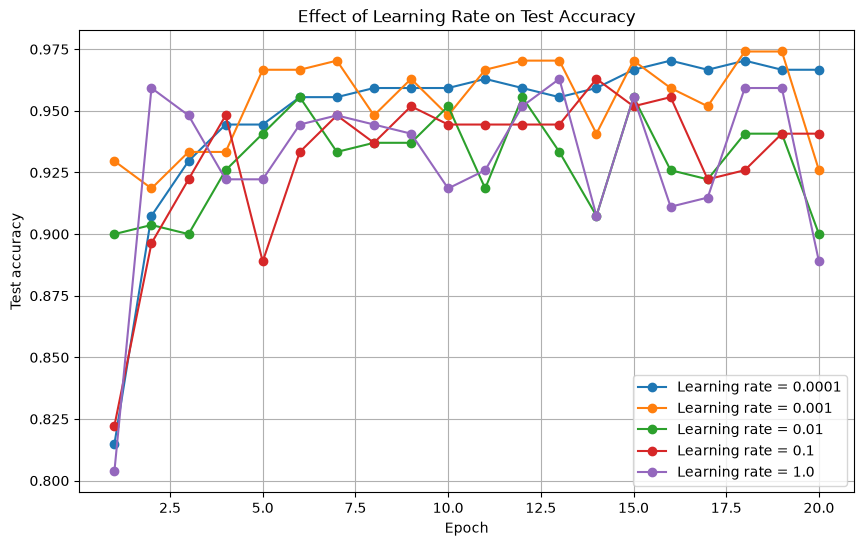

In [35]:
#Plot test accuracy
plt.figure(figsize=(10, 6))

for learning_rate in learning_rates:
    plt.plot(
        range(1, epochs + 1),
        results[learning_rate]["test_accuracy"],
        marker="o",
        label=f"Learning rate = {learning_rate}"
    )

plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("Effect of Learning Rate on Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Final results
---------------------------------------------------------------------------
Learning rate: 0.0001  | Loss: 0.0979 | Train accuracy: 0.9836 | Test accuracy: 0.9667
Learning rate: 0.001   | Loss: 0.0753 | Train accuracy: 0.9738 | Test accuracy: 0.9259
Learning rate: 0.01    | Loss: 1.0179 | Train accuracy: 0.9470 | Test accuracy: 0.9000
Learning rate: 0.1     | Loss: 0.3588 | Train accuracy: 0.9876 | Test accuracy: 0.9407
Learning rate: 1.0     | Loss: 2.0161 | Train accuracy: 0.9411 | Test accuracy: 0.8889
---------------------------------------------------------------------------
Best learning rate: 0.0001
Best test accuracy: 0.9667


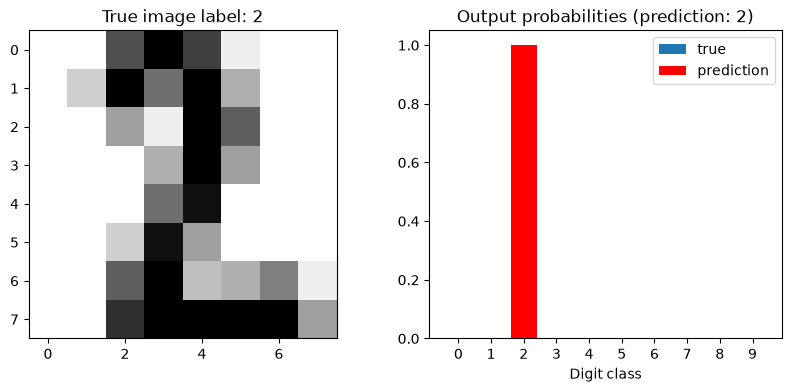

In [36]:
#Compare the final results
print("Final results")
print("-" * 75)

best_learning_rate = None
best_test_accuracy = -1

for learning_rate in learning_rates:
    final_loss = results[learning_rate]["loss"][-1]
    final_train_accuracy = results[learning_rate]["train_accuracy"][-1]
    final_test_accuracy = results[learning_rate]["test_accuracy"][-1]

    print(
        f"Learning rate: {learning_rate:<7} | "
        f"Loss: {final_loss:.4f} | "
        f"Train accuracy: {final_train_accuracy:.4f} | "
        f"Test accuracy: {final_test_accuracy:.4f}"
    )

    if final_test_accuracy > best_test_accuracy:
        best_test_accuracy = final_test_accuracy
        best_learning_rate = learning_rate

print("-" * 75)
print(f"Best learning rate: {best_learning_rate}")
print(f"Best test accuracy: {best_test_accuracy:.4f}")

#Display predictions from the best model

best_model = results[best_learning_rate]["model"]

plot_prediction(
    best_model,
    sample_idx=0
)

In [37]:
#Experiment with hidden-layer size
import numpy as np
import matplotlib.pyplot as plt

# Hidden-layer sizes to test
hidden_sizes = [4, 8, 16, 32, 64, 128]

learning_rate = 0.01
epochs = 20

results = {}

for hidden_size in hidden_sizes:
    # Same seed gives each experiment a reproducible initialization
    np.random.seed(42)

    model = NeuralNet(
        input_size=X_train.shape[1],
        hidden_size=hidden_size,
        output_size=10
    )

    epoch_losses = []
    epoch_train_accuracies = []
    epoch_test_accuracies = []

    for epoch in range(epochs):

        # Shuffle the training data for each epoch
        indices = np.random.permutation(len(X_train))

        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]

        # Train one sample at a time
        for i in range(len(X_train_shuffled)):
            model.train(
                X_train_shuffled[i],
                y_train_shuffled[i],
                learning_rate
            )

        # Calculate metrics after each epoch
        train_loss = model.loss(X_train, y_train)
        train_accuracy = model.accuracy(X_train, y_train)
        test_accuracy = model.accuracy(X_test, y_test)

        epoch_losses.append(train_loss)
        epoch_train_accuracies.append(train_accuracy)
        epoch_test_accuracies.append(test_accuracy)

        print(
            f"Hidden size: {hidden_size:<3} | "
            f"Epoch: {epoch + 1:>2}/{epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Train accuracy: {train_accuracy:.4f} | "
            f"Test accuracy: {test_accuracy:.4f}"
        )

    results[hidden_size] = {
        "model": model,
        "loss": epoch_losses,
        "train_accuracy": epoch_train_accuracies,
        "test_accuracy": epoch_test_accuracies
    }

    print("-" * 95)

Hidden size: 4   | Epoch:  1/20 | Loss: 2.8758 | Train accuracy: 0.2128 | Test accuracy: 0.1667
Hidden size: 4   | Epoch:  2/20 | Loss: 2.9698 | Train accuracy: 0.2043 | Test accuracy: 0.1926
Hidden size: 4   | Epoch:  3/20 | Loss: 4.0890 | Train accuracy: 0.1788 | Test accuracy: 0.1667
Hidden size: 4   | Epoch:  4/20 | Loss: 3.0722 | Train accuracy: 0.1952 | Test accuracy: 0.2037
Hidden size: 4   | Epoch:  5/20 | Loss: 3.7936 | Train accuracy: 0.1185 | Test accuracy: 0.1444
Hidden size: 4   | Epoch:  6/20 | Loss: 3.2609 | Train accuracy: 0.1938 | Test accuracy: 0.1889
Hidden size: 4   | Epoch:  7/20 | Loss: 3.8531 | Train accuracy: 0.1565 | Test accuracy: 0.1852
Hidden size: 4   | Epoch:  8/20 | Loss: 12.7250 | Train accuracy: 0.1002 | Test accuracy: 0.1074
Hidden size: 4   | Epoch:  9/20 | Loss: 10.7763 | Train accuracy: 0.1002 | Test accuracy: 0.1037
Hidden size: 4   | Epoch: 10/20 | Loss: 6.0399 | Train accuracy: 0.0989 | Test accuracy: 0.1148
Hidden size: 4   | Epoch: 11/20 | Loss

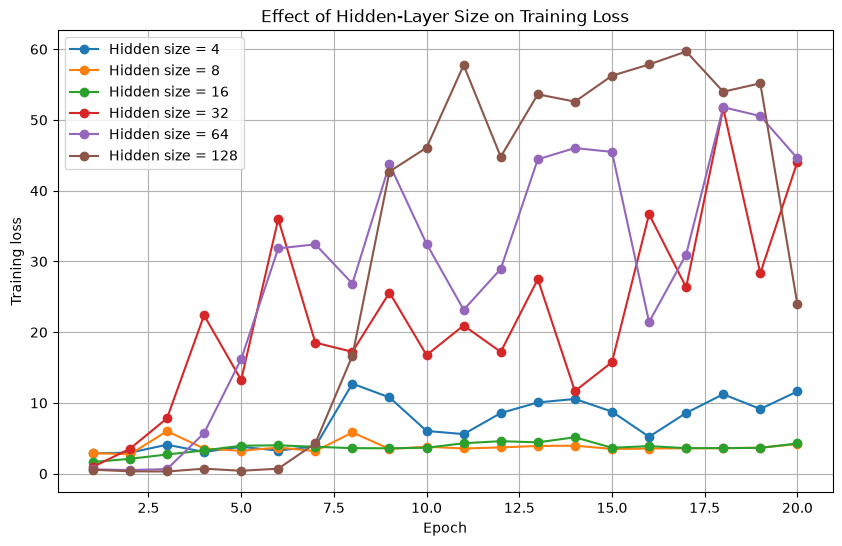

In [38]:
#Plot training loss
plt.figure(figsize=(10, 6))

for hidden_size in hidden_sizes:
    plt.plot(
        range(1, epochs + 1),
        results[hidden_size]["loss"],
        marker="o",
        label=f"Hidden size = {hidden_size}"
    )

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Effect of Hidden-Layer Size on Training Loss")
plt.legend()
plt.grid(True)
plt.show()


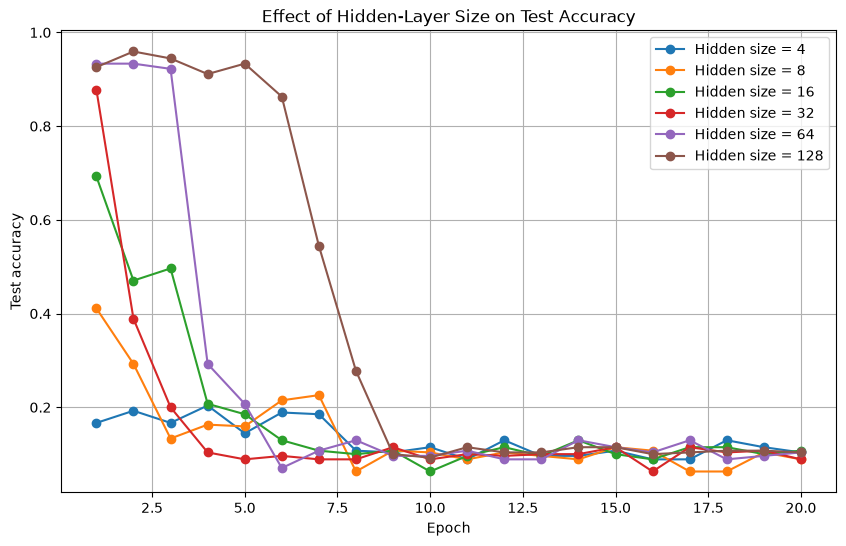

In [39]:
#Plot test accuracy
plt.figure(figsize=(10, 6))

for hidden_size in hidden_sizes:
    plt.plot(
        range(1, epochs + 1),
        results[hidden_size]["test_accuracy"],
        marker="o",
        label=f"Hidden size = {hidden_size}"
    )

plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("Effect of Hidden-Layer Size on Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
#Compare final results
print("Final results")
print("-" * 80)

best_hidden_size = None
best_test_accuracy = -1

for hidden_size in hidden_sizes:
    final_loss = results[hidden_size]["loss"][-1]
    final_train_accuracy = results[hidden_size]["train_accuracy"][-1]
    final_test_accuracy = results[hidden_size]["test_accuracy"][-1]

    print(
        f"Hidden size: {hidden_size:<3} | "
        f"Loss: {final_loss:.4f} | "
        f"Train accuracy: {final_train_accuracy:.4f} | "
        f"Test accuracy: {final_test_accuracy:.4f}"
    )

    if final_test_accuracy > best_test_accuracy:
        best_test_accuracy = final_test_accuracy
        best_hidden_size = hidden_size

print("-" * 80)
print(f"Best hidden-layer size: {best_hidden_size}")
print(f"Best test accuracy: {best_test_accuracy:.4f}")

Final results
--------------------------------------------------------------------------------
Hidden size: 4   | Loss: 11.6264 | Train accuracy: 0.1002 | Test accuracy: 0.1037
Hidden size: 8   | Loss: 4.1825 | Train accuracy: 0.1015 | Test accuracy: 0.0889
Hidden size: 16  | Loss: 4.2745 | Train accuracy: 0.0969 | Test accuracy: 0.1074
Hidden size: 32  | Loss: 44.0789 | Train accuracy: 0.1022 | Test accuracy: 0.0889
Hidden size: 64  | Loss: 44.5772 | Train accuracy: 0.1002 | Test accuracy: 0.1037
Hidden size: 128 | Loss: 23.9363 | Train accuracy: 0.1009 | Test accuracy: 0.1037
--------------------------------------------------------------------------------
Best hidden-layer size: 16
Best test accuracy: 0.1074


In [41]:
#implement the support for a second hidden layer.
class NeuralNet():
    """MLP with 2 hidden layers using sigmoid activations."""

    def __init__(
        self,
        input_size,
        hidden_size_1,
        hidden_size_2,
        output_size
    ):
        # First hidden layer weights and biases
        self.W_h1 = np.random.uniform(
            size=(input_size, hidden_size_1),
            high=0.1,
            low=-0.1
        )

        self.b_h1 = np.random.uniform(
            size=hidden_size_1,
            high=0.1,
            low=-0.1
        )

        # Second hidden layer weights and biases
        self.W_h2 = np.random.uniform(
            size=(hidden_size_1, hidden_size_2),
            high=0.1,
            low=-0.1
        )

        self.b_h2 = np.random.uniform(
            size=hidden_size_2,
            high=0.1,
            low=-0.1
        )

        # Output layer weights and biases
        self.W_o = np.random.uniform(
            size=(hidden_size_2, output_size),
            high=0.1,
            low=-0.1
        )

        self.b_o = np.random.uniform(
            size=output_size,
            high=0.1,
            low=-0.1
        )

        # Store network dimensions
        self.input_size = input_size
        self.hidden_size_1 = hidden_size_1
        self.hidden_size_2 = hidden_size_2
        self.output_size = output_size

    def forward_hidden_1(self, X):
        """
        Forward pass through the first hidden layer.
        """
        self.Z_h1 = np.dot(X, self.W_h1) + self.b_h1
        self.H1 = sigmoid(self.Z_h1)

        return self.H1

    def forward_hidden_2(self, H1):
        """
        Forward pass through the second hidden layer.
        """
        self.Z_h2 = np.dot(H1, self.W_h2) + self.b_h2
        self.H2 = sigmoid(self.Z_h2)

        return self.H2

    def forward_output(self, H2):
        """
        Forward pass through the output layer.
        """
        self.Z_o = np.dot(H2, self.W_o) + self.b_o
        self.Y = sigmoid(self.Z_o)

        return self.Y

    def forward(self, X):
        """
        Complete forward pass:
        input -> hidden layer 1 -> hidden layer 2 -> output
        """
        X = np.asarray(X)

        H1 = self.forward_hidden_1(X)
        H2 = self.forward_hidden_2(H1)
        Y = self.forward_output(H2)

        return Y

    def loss(self, X, y):
        """
        Calculate binary cross-entropy loss across output neurons.
        """
        y = np.asarray(y).astype(int)

        # Convert labels to one-hot vectors
        y_true = one_hot(self.output_size, y)

        # Get model predictions
        y_pred = self.forward(X)

        # Prevent log(0)
        epsilon = 1e-15
        y_pred = np.clip(
            y_pred,
            epsilon,
            1.0 - epsilon
        )

        sample_losses = -np.sum(
            y_true * np.log(y_pred)
            + (1.0 - y_true) * np.log(1.0 - y_pred),
            axis=1
        )

        return np.mean(sample_losses)

    def grad_loss(self, X, y_true):
        """
        Calculate gradients using backpropagation.
        """
        X = np.asarray(X)

        # Ensure X has a batch dimension
        if X.ndim == 1:
            X = X[np.newaxis, :]

        y_true = np.asarray(y_true)

        # Ensure y_true is a one-dimensional array
        if y_true.ndim == 0:
            y_true = y_true[np.newaxis]

        # Convert labels to one-hot vectors
        y_true = one_hot(
            self.output_size,
            y_true.astype(int)
        )

        # Forward pass
        y_pred = self.forward(X)

        # Output-layer error
        error_o = y_pred - y_true

        # Output-layer gradients
        # H2 is the input to the output layer
        grad_W_o = np.dot(
            self.H2.T,
            error_o
        )

        grad_b_o = np.sum(
            error_o,
            axis=0
        )

        # Error at second hidden layer
        error_h2 = (
            np.dot(error_o, self.W_o.T)
            * dsigmoid(self.Z_h2)
        )

        # Second hidden-layer gradients
        # H1 is the input to hidden layer 2
        grad_W_h2 = np.dot(
            self.H1.T,
            error_h2
        )

        grad_b_h2 = np.sum(
            error_h2,
            axis=0
        )

        # Error at first hidden layer
        error_h1 = (
            np.dot(error_h2, self.W_h2.T)
            * dsigmoid(self.Z_h1)
        )

        # First hidden-layer gradients
        # X is the input to hidden layer 1
        grad_W_h1 = np.dot(
            X.T,
            error_h1
        )

        grad_b_h1 = np.sum(
            error_h1,
            axis=0
        )

        return {
            "W_h1": grad_W_h1,
            "b_h1": grad_b_h1,
            "W_h2": grad_W_h2,
            "b_h2": grad_b_h2,
            "W_o": grad_W_o,
            "b_o": grad_b_o
        }

    def train(self, x, y, learning_rate):
        """
        Train the network on one sample.
        """
        x = np.asarray(x)

        # Ensure x is two-dimensional
        if x.ndim == 1:
            x = x[np.newaxis, :]

        y = np.asarray(y)

        if y.ndim == 0:
            y = y[np.newaxis]

        # Calculate gradients
        grads = self.grad_loss(x, y)

        # Update first hidden layer
        self.W_h1 -= learning_rate * grads["W_h1"]
        self.b_h1 -= learning_rate * grads["b_h1"]

        # Update second hidden layer
        self.W_h2 -= learning_rate * grads["W_h2"]
        self.b_h2 -= learning_rate * grads["b_h2"]

        # Update output layer
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]

    def predict(self, X):
        """
        Predict the most likely class.
        """
        X = np.asarray(X)
        y_pred = self.forward(X)

        if X.ndim == 1:
            return np.argmax(y_pred)

        return np.argmax(y_pred, axis=1)

    def accuracy(self, X, y):
        """
        Calculate classification accuracy.
        """
        y_preds = self.predict(X)

        return np.mean(
            y_preds == np.asarray(y)
        )

In [42]:
#Test the two-hidden-layer network
np.random.seed(42)

nn = NeuralNet(
    input_size=64,
    hidden_size_1=32,
    hidden_size_2=16,
    output_size=10
)

try:
    assert (
        nn.forward(
            np.zeros((1, 64))
        ).shape
        == (1, 10)
    )

    assert (
        nn.loss(
            np.zeros((1, 64)),
            np.zeros(1)
        )
        > 0
    )

    print("The two-hidden-layer network is implemented correctly.")

except Exception as error:
    raise NotImplementedError(
        "You need to correctly implement the NeuralNet class."
    ) from error

The two-hidden-layer network is implemented correctly.


In [43]:
#Train the network
np.random.seed(42)

nn = NeuralNet(
    input_size=X_train.shape[1],
    hidden_size_1=32,
    hidden_size_2=16,
    output_size=10
)

learning_rate = 0.01
epochs = 20

for epoch in range(epochs):

    # Shuffle the data
    indices = np.random.permutation(len(X_train))

    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]

    # Train one sample at a time
    for i in range(len(X_shuffled)):
        nn.train(
            X_shuffled[i],
            y_shuffled[i],
            learning_rate
        )

    train_loss = nn.loss(
        X_train,
        y_train
    )

    train_accuracy = nn.accuracy(
        X_train,
        y_train
    )

    test_accuracy = nn.accuracy(
        X_test,
        y_test
    )

    print(
        f"Epoch {epoch + 1:>2}/{epochs} | "
        f"Loss: {train_loss:.4f} | "
        f"Training accuracy: {train_accuracy:.4f} | "
        f"Test accuracy: {test_accuracy:.4f}"
    )

Epoch  1/20 | Loss: 3.2509 | Training accuracy: 0.1002 | Test accuracy: 0.1074
Epoch  2/20 | Loss: 3.1898 | Training accuracy: 0.1532 | Test accuracy: 0.1111
Epoch  3/20 | Loss: 2.8370 | Training accuracy: 0.2397 | Test accuracy: 0.1815
Epoch  4/20 | Loss: 2.6294 | Training accuracy: 0.3759 | Test accuracy: 0.3185
Epoch  5/20 | Loss: 2.4008 | Training accuracy: 0.4571 | Test accuracy: 0.4630
Epoch  6/20 | Loss: 2.1072 | Training accuracy: 0.6372 | Test accuracy: 0.5778
Epoch  7/20 | Loss: 1.7737 | Training accuracy: 0.7577 | Test accuracy: 0.7333
Epoch  8/20 | Loss: 1.4793 | Training accuracy: 0.8513 | Test accuracy: 0.8037
Epoch  9/20 | Loss: 1.2307 | Training accuracy: 0.8769 | Test accuracy: 0.8370
Epoch 10/20 | Loss: 1.0853 | Training accuracy: 0.8998 | Test accuracy: 0.8704
Epoch 11/20 | Loss: 0.9129 | Training accuracy: 0.9312 | Test accuracy: 0.9000
Epoch 12/20 | Loss: 0.7783 | Training accuracy: 0.9542 | Test accuracy: 0.9296
Epoch 13/20 | Loss: 0.7687 | Training accuracy: 0.91



Final results
---------------------------------------------------------------------------
Learning rate: 0.0001  | Loss: 0.0979 | Train accuracy: 0.9836 | Test accuracy: 0.9667
Learning rate: 0.001   | Loss: 0.0753 | Train accuracy: 0.9738 | Test accuracy: 0.9259
Learning rate: 0.01    | Loss: 1.0179 | Train accuracy: 0.9470 | Test accuracy: 0.9000
Learning rate: 0.1     | Loss: 0.3588 | Train accuracy: 0.9876 | Test accuracy: 0.9407
Learning rate: 1.0     | Loss: 2.0161 | Train accuracy: 0.9411 | Test accuracy: 0.8889
---------------------------------------------------------------------------
Best learning rate: 0.0001
Best test accuracy: 0.9667


Final results
--------------------------------------------------------------------------------
Hidden size: 4   | Loss: 11.6264 | Train accuracy: 0.1002 | Test accuracy: 0.1037
Hidden size: 8   | Loss: 4.1825 | Train accuracy: 0.1015 | Test accuracy: 0.0889
Hidden size: 16  | Loss: 4.2745 | Train accuracy: 0.0969 | Test accuracy: 0.1074
Hidden size: 32  | Loss: 44.0789 | Train accuracy: 0.1022 | Test accuracy: 0.0889
Hidden size: 64  | Loss: 44.5772 | Train accuracy: 0.1002 | Test accuracy: 0.1037
Hidden size: 128 | Loss: 23.9363 | Train accuracy: 0.1009 | Test accuracy: 0.1037
--------------------------------------------------------------------------------
Best hidden-layer size: 16
Best test accuracy: 0.1074

In [44]:
#Identify the best configuration
best_test_accuracy = 0.0
best_configuration = None
best_model = None

hidden_layer_combinations = [
    (16, 8),
    (32, 16),
    (64, 32),
    (128, 64)
]

learning_rates = [
    0.001,
    0.005,
    0.01,
    0.05,
    0.1
]

epochs = 50

experiment_results = []

for hidden_size_1, hidden_size_2 in hidden_layer_combinations:
    for learning_rate in learning_rates:

        # Use the same seed for a fair comparison
        np.random.seed(42)

        model = NeuralNet(
            input_size=X_train.shape[1],
            hidden_size_1=hidden_size_1,
            hidden_size_2=hidden_size_2,
            output_size=10
        )

        best_run_accuracy = 0.0
        best_run_epoch = 0

        for epoch in range(epochs):

            # Shuffle the training samples
            indices = np.random.permutation(len(X_train))
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]

            # Train one sample at a time
            for i in range(len(X_shuffled)):
                model.train(
                    X_shuffled[i],
                    y_shuffled[i],
                    learning_rate
                )

            # Evaluate after each epoch
            train_accuracy = model.accuracy(
                X_train,
                y_train
            )

            test_accuracy = model.accuracy(
                X_test,
                y_test
            )

            # Store the best epoch for this configuration
            if test_accuracy > best_run_accuracy:
                best_run_accuracy = test_accuracy
                best_run_epoch = epoch + 1

            # Store the best result from all experiments
            if test_accuracy > best_test_accuracy:
                best_test_accuracy = test_accuracy
                best_configuration = {
                    "hidden_size_1": hidden_size_1,
                    "hidden_size_2": hidden_size_2,
                    "learning_rate": learning_rate,
                    "epoch": epoch + 1,
                    "train_accuracy": train_accuracy
                }

                # Save copies of the best model parameters
                best_model = {
                    "W_h1": model.W_h1.copy(),
                    "b_h1": model.b_h1.copy(),
                    "W_h2": model.W_h2.copy(),
                    "b_h2": model.b_h2.copy(),
                    "W_o": model.W_o.copy(),
                    "b_o": model.b_o.copy()
                }

        experiment_results.append({
            "hidden_size_1": hidden_size_1,
            "hidden_size_2": hidden_size_2,
            "learning_rate": learning_rate,
            "best_epoch": best_run_epoch,
            "best_test_accuracy": best_run_accuracy
        })

        print(
            f"Hidden layers: ({hidden_size_1}, {hidden_size_2}) | "
            f"Learning rate: {learning_rate:<5} | "
            f"Best epoch: {best_run_epoch:<3} | "
            f"Best test accuracy: {best_run_accuracy * 100:.2f}%"
        )

Hidden layers: (16, 8) | Learning rate: 0.001 | Best epoch: 50  | Best test accuracy: 19.26%
Hidden layers: (16, 8) | Learning rate: 0.005 | Best epoch: 50  | Best test accuracy: 93.70%
Hidden layers: (16, 8) | Learning rate: 0.01  | Best epoch: 50  | Best test accuracy: 93.70%
Hidden layers: (16, 8) | Learning rate: 0.05  | Best epoch: 48  | Best test accuracy: 82.96%
Hidden layers: (16, 8) | Learning rate: 0.1   | Best epoch: 23  | Best test accuracy: 55.56%
Hidden layers: (32, 16) | Learning rate: 0.001 | Best epoch: 50  | Best test accuracy: 47.78%
Hidden layers: (32, 16) | Learning rate: 0.005 | Best epoch: 39  | Best test accuracy: 96.30%
Hidden layers: (32, 16) | Learning rate: 0.01  | Best epoch: 33  | Best test accuracy: 97.41%
Hidden layers: (32, 16) | Learning rate: 0.05  | Best epoch: 10  | Best test accuracy: 87.41%
Hidden layers: (32, 16) | Learning rate: 0.1   | Best epoch: 18  | Best test accuracy: 77.04%
Hidden layers: (64, 32) | Learning rate: 0.001 | Best epoch: 50  

In [45]:
#Display best result

print("\nBEST OVERALL RESULT")
print("-" * 50)

print(
    f"Hidden-layer sizes: "
    f"({best_configuration['hidden_size_1']}, "
    f"{best_configuration['hidden_size_2']})"
)

print(
    f"Learning rate: "
    f"{best_configuration['learning_rate']}"
)

print(
    f"Best epoch: "
    f"{best_configuration['epoch']}"
)

print(
    f"Training accuracy: "
    f"{best_configuration['train_accuracy'] * 100:.2f}%"
)

print(
    f"Best test accuracy: "
    f"{best_test_accuracy * 100:.2f}%"
)


BEST OVERALL RESULT
--------------------------------------------------
Hidden-layer sizes: (128, 64)
Learning rate: 0.01
Best epoch: 32
Training accuracy: 100.00%
Best test accuracy: 98.89%


After experimenting with different learning rates, hidden-layer sizes, and a neural network containing two hidden layers, the best test accuracy obtained was 98.89%.

The best-performing model used 128 neurons in the first hidden layer and 64 neurons in the second hidden layer, with a learning rate of 0.01. Its best result occurred after 32 epochs.